# Fatores Socioeconômicos no Desempenho do ENEM × Indicadores Estaduais do IBGE
**Entrega 1 — Análise Exploratória, ETL e Dashboard de KPIs**

**Objetivo:** unir uma amostra de microdados do ENEM a indicadores estaduais do IBGE para (i) gerar estatísticas descritivas, (ii) calcular 20 KPIs e (iii) construir visualizações que sustentem o storytelling do projeto.

> 📌 **Nota metodológica (dados reais):**
> - **ENEM 2023 (INEP):** amostra estratificada por UF (4% de cada UF, `SEED = 42`) dos **concluintes do ensino médio em 2023** que informaram escola pública ou privada. A amostra é gerada por `baixar_dados.py`, que lê o CSV oficial em blocos, e salva em `dados/processados/enem_amostra.parquet`. Este notebook lê **só essa amostra**.
> - **Por que 2023?** Nos microdados de 2024 e 2025, o INEP separou notas e questionário socioeconômico em arquivos sem chave de ligação. Com isso, não é possível cruzar renda com nota no nível do aluno. O ENEM 2023 é a edição mais recente que permite esse cruzamento.
> - **Indicadores estaduais (`dados/ibge_uf.csv`):** população (Censo 2022), rendimento domiciliar per capita (PNAD Contínua 2023) e IDHM 2023 (Radar IDHM, PNUD/Ipea/FJP). Fonte e ano de cada indicador estão no próprio CSV.
> - **UF do aluno = UF onde fez a prova** (`SG_UF_PROVA`). Desde 2022 o INEP não divulga a UF de residência.
> - A simulação usada na versão anterior continua disponível como *fallback* (`USAR_DADOS_REAIS = False`), por exemplo para rodar o notebook sem os dados baixados.

## 1. Configuração e importações

In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Funções do projeto (fonte única, compartilhada com a Entrega 2)
from src.dados import COLS_NOTAS, carregar_dados, etl, recorte_presentes
from src.estilo import AZUL, CORES_ESCOLA, CORES_RENDA, DESTAQUE, aplicar_estilo
from src.kpis import calcular_kpis, exibir_kpis

warnings.filterwarnings("ignore")

# True = microdados reais (INEP + IBGE) | False = simulação reprodutível (fallback)
USAR_DADOS_REAIS = True

# Estilo global dos gráficos (paleta validada para daltonismo, em src/estilo.py)
aplicar_estilo()

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

## 2. Coleta e carregamento dos dados
As funções de carga ficam em [`src/dados.py`](src/dados.py). A amostra é gerada antes, por [`baixar_dados.py`](baixar_dados.py) (download do INEP + leitura em blocos + amostragem estratificada por UF).

**Dados reais (`USAR_DADOS_REAIS = True`):**
- `carregar_ibge_real()` lê `dados/ibge_uf.csv` e mantém as colunas `UF`, `REGIAO`, `IDH_ESTADUAL`, `RENDA_PER_CAPITA` (R$/mês) e `POPULACAO`.
- `carregar_enem_real()` lê a amostra em Parquet e **traduz as colunas do INEP** para os nomes usados no restante do notebook:

| Coluna no notebook | Coluna(s) no INEP 2023 | Transformação |
|---|---|---|
| `UF` | `SG_UF_PROVA` | UF de aplicação da prova |
| `TP_ESCOLA` | `TP_ESCOLA` | 2 → "Pública", 3 → "Privada" |
| `Q006` | `Q006` | renda familiar mensal, faixas A (nenhuma renda) a Q (> R$ 26.400) |
| `NU_NOTA_*` | `NU_NOTA_CN/CH/LC/MT/REDACAO` | sem alteração |
| `TP_PRESENCA` | `TP_PRESENCA_CN/CH/LC/MT` | 2 se eliminado em alguma prova; 1 se presente nas quatro; 0 caso contrário (faltou a pelo menos um dia) |

Colunas extras (`TP_SEXO`, `TP_COR_RACA`, `TP_FAIXA_ETARIA`, `Q001`, `Q002`, `Q005`, `Q024`, `Q025`, `TP_STATUS_REDACAO`) são mantidas para a modelagem da Entrega 2.

**Simulação (`USAR_DADOS_REAIS = False`):** `gerar_ibge()` e `gerar_enem()` produzem as mesmas colunas principais com relações plausíveis (renda e escola privada ↑ nota; IDH ↑ nota). Os valores do IBGE nesse modo são aproximados.

`TP_PRESENCA`: 0 = faltou · 1 = presente · 2 = eliminado.

In [2]:
df_ibge, df_enem = carregar_dados(USAR_DADOS_REAIS)

print(f"Modo: {'DADOS REAIS (INEP 2023 + IBGE/PNUD)' if USAR_DADOS_REAIS else 'SIMULAÇÃO'}")
print(f"ENEM: {df_enem.shape[0]:,} linhas × {df_enem.shape[1]} colunas | IBGE: {df_ibge.shape}")
display(df_ibge.head().style.format({"IDH_ESTADUAL": "{:.3f}", "RENDA_PER_CAPITA": "R$ {:,.0f}", "POPULACAO": "{:,}"}))
df_enem.head()

Modo: DADOS REAIS (INEP 2023 + IBGE/PNUD)
ENEM: 56,048 linhas × 18 colunas | IBGE: (27, 5)


,UF,REGIAO,IDH_ESTADUAL,RENDA_PER_CAPITA,POPULACAO
0,RO,Norte,0.768,"R$ 1,525","1,581,196"
1,AC,Norte,0.740,"R$ 1,065","830,018"
2,AM,Norte,0.764,"R$ 1,165","3,941,613"
3,RR,Norte,0.769,"R$ 1,452","636,707"
4,PA,Norte,0.753,"R$ 1,262","8,120,131"


,UF,TP_ESCOLA,Q006,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_PRESENCA,TP_SEXO,TP_COR_RACA,TP_FAIXA_ETARIA,Q001,Q002,Q005,Q024,Q025,TP_STATUS_REDACAO
0,AC,Pública,B,NaN,495.40,509.00,NaN,460.00,0,M,3,3,H,F,2,A,B,1
1,AC,Pública,B,456.80,534.50,504.50,628.20,780.00,1,M,3,3,E,E,2,A,A,1
2,AC,Pública,I,530.50,543.50,537.90,501.70,540.00,1,M,1,3,D,G,3,B,B,1
3,AC,Pública,B,437.80,420.50,405.40,576.60,860.00,1,F,3,3,B,E,5,A,B,1
4,AC,Pública,E,605.90,598.20,611.40,524.20,940.00,1,F,1,3,H,E,3,A,B,1


## 3. ETL e Engenharia de Recursos
Função `etl()` em [`src/dados.py`](src/dados.py).

Etapas: **(1)** diagnóstico de nulos → **(2)** merge com IBGE (`m:1`, validado) → **(3)** `NOTA_FINAL` → **(4)** faixas de renda → **(5)** tratamento de nulos.

**Decisão de tratamento:** nulos nas notas de quem faltou/foi eliminado são *estruturais* (não há prova), então **não são imputados**: a análise de desempenho usa apenas **presentes com as 5 notas válidas**, enquanto indicadores de abstenção usam a base completa. Nulos "acidentais" em presentes (falha de registro) são removidos do recorte de desempenho. Na amostra real do ENEM 2023 essa situação não ocorre: todo nulo de nota corresponde a falta ou eliminação. A regra continua no código porque a simulação gera esses casos.

Mapeamento de `Q006` (salário mínimo de 2023 = R$ 1.320): **A–D** (até 2 SM) → Baixa Renda · **E–H** (2 a 5 SM) → Média Renda · **I–Q** (> 5 SM) → Alta Renda.

In [3]:
df = etl(df_enem, df_ibge)

# Recorte analítico: presentes com NOTA_FINAL válida
df_pres = recorte_presentes(df)

print(f"Base completa: {len(df):,} | Presentes com notas válidas: {len(df_pres):,} "
      f"({len(df_pres)/len(df):.1%})")
df_pres[["UF", "TP_ESCOLA", "FAIXA_RENDA", "NOTA_FINAL", "IDH_ESTADUAL"]].head()

Nulos por coluna (antes do tratamento):
NU_NOTA_CN           13841
NU_NOTA_CH           12034
NU_NOTA_LC           12034
NU_NOTA_MT           13841
NU_NOTA_REDACAO      12034
TP_STATUS_REDACAO    12034 

Base completa: 56,048 | Presentes com notas válidas: 42,032 (75.0%)


,UF,TP_ESCOLA,FAIXA_RENDA,NOTA_FINAL,IDH_ESTADUAL
1,AC,Pública,Baixa Renda,580.80,0.74
2,AC,Pública,Alta Renda,530.72,0.74
3,AC,Pública,Baixa Renda,540.06,0.74
4,AC,Pública,Média Renda,655.94,0.74
5,AC,Pública,Baixa Renda,437.82,0.74


## 4. Estatísticas descritivas
Visão geral das notas e das variáveis categóricas antes de calcular os KPIs.

In [4]:
print("=== Estatísticas descritivas das notas (presentes válidos) ===")
display(df_pres[COLS_NOTAS + ["NOTA_FINAL"]].describe().T)

print("\n=== Distribuição de variáveis categóricas (base completa) ===")
for col in ["TP_ESCOLA", "FAIXA_RENDA", "TP_PRESENCA"]:
    display(df[col].value_counts(normalize=True).mul(100).round(1).rename("%").to_frame())

print("\n=== Nota final média por tipo de escola e faixa de renda ===")
display(df_pres.pivot_table(index="FAIXA_RENDA", columns="TP_ESCOLA", values="NOTA_FINAL",
                            aggfunc=["mean", "count"], observed=True))

=== Estatísticas descritivas das notas (presentes válidos) ===


,count,mean,std,min,25%,50%,75%,max
NU_NOTA_CN,"42,032.00",489.00,84.46,0.00,434.30,486.60,544.00,843.40
NU_NOTA_CH,"42,032.00",518.32,85.10,0.00,463.80,524.30,578.00,799.50
NU_NOTA_LC,"42,032.00",514.51,73.51,0.00,467.80,519.30,566.40,768.90
NU_NOTA_MT,"42,032.00",530.68,128.63,0.00,428.90,519.10,624.60,958.60
NU_NOTA_REDACAO,"42,032.00",628.66,215.01,0.00,520.00,640.00,800.00,980.00
NOTA_FINAL,"42,032.00",536.24,95.84,57.62,471.50,535.87,603.60,820.38



=== Distribuição de variáveis categóricas (base completa) ===


,%
TP_ESCOLA,
Pública,83.40
Privada,16.60


,%
FAIXA_RENDA,
Baixa Renda,65.80
Média Renda,22.60
Alta Renda,11.60


,%
TP_PRESENCA,
1,75.00
0,24.80
2,0.20



=== Nota final média por tipo de escola e faixa de renda ===


mean           count        
TP_ESCOLA   Privada Pública Privada Pública
FAIXA_RENDA                                
Baixa Renda  577.36  501.52    1598   24296
Média Renda  606.34  546.07    3064    7238
Alta Renda   638.63  578.04    4088    1748

## 5. Cálculo dos 20 KPIs
Os KPIs estão organizados em **4 eixos** (5 por eixo). O cálculo está em `calcular_kpis()` ([`src/kpis.py`](src/kpis.py)): cada indicador é registrado pela função auxiliar `kpi()` em uma tabela única, com valor numérico, unidade e uma observação de contexto (ex.: qual UF). Tabelas intermediárias por UF ficam guardadas para reutilização nos gráficos.

**Definições adotadas:**
- *Exatas* = média de Ciências da Natureza e Matemática por aluno.
- *Abstenção* = `TP_PRESENCA == 0` sobre a base completa; *Presença* = `TP_PRESENCA == 1`.
- *Índice de Desigualdade Regional* = coeficiente de variação (%) das médias estaduais da nota final.
- *Gap de renda entre UFs* = nota média da UF de maior renda per capita − nota média da UF de menor renda per capita.

In [5]:
df_kpis, aux = calcular_kpis(df, df_pres, df_ibge)

# Tabelas intermediárias reaproveitadas nos gráficos
media_uf, tab_uf, med_escola, corr_idh = aux["media_uf"], aux["tab_uf"], aux["med_escola"], aux["corr_idh"]

assert len(df_kpis) == 20, f"Esperados 20 KPIs, encontrados {len(df_kpis)}"
exibir_kpis(df_kpis)


A) Desempenho Acadêmico


,KPI,Valor,Unidade,Observação
#,,,,
1,Média Geral por UF (melhor UF),561.16,pts,MG | pior: AM (494.4)
2,Mediana da Redação,640.00,pts,
3,Desvio-padrão de Exatas (CN+MT),98.81,pts,
4,Taxa de Notas > 700 (Nota Final),4.05,%,
5,Taxa de Zeros na Redação,4.11,%,



B) Perfil Socioeconômico


,KPI,Valor,Unidade,Observação
#,,,,
6,"Média de Renda por UF (índice Q006, maior)",5.27,índice 0–16,SC | menor: CE (1.82)
7,% Escola Pública,83.43,%,Privada: 16.6%
8,Razão de Notas Privada/Pública,1.20,razão,Privada 616.1 vs Pública 515.2
9,Distribuição por Faixa de Renda (% Baixa Renda),65.82,%,Média: 22.6% | Alta: 11.6%
10,% Abstenção,24.85,%,



C) Cruzamento IBGE


,KPI,Valor,Unidade,Observação
#,,,,
11,"Correlação IDH × Nota Média (Pearson, nível UF)",0.71,r,n = 27 UFs
12,Gap de Nota: UF de maior vs menor renda per capita,58.01,pts,DF − MA
13,Densidade de Inscritos / 100 mil hab. (amostra),27.60,insc./100k,maior UF: CE (49.55)
14,Taxa de Abstenção por Renda (Baixa − Alta),19.76,p.p.,Baixa 29.6% | Média 18.6% | Alta 9.9%
15,Índice de Desigualdade Regional (CV das médias por UF),4.28,%,



D) Operacional / Resumo


,KPI,Valor,Unidade,Observação
#,,,,
16,Total de Inscritos na Amostra,"56,048.00",alunos,
17,Média Geral de Presença,74.99,%,
18,% Alunos Baixa Renda com Nota > 600,14.30,%,"base: 25,894 alunos"
19,Maior Nota Geral,820.38,pts,
20,Menor Nota Geral,57.62,pts,


## 6. Painel de visualizações (dashboard analítico)
Cinco gráficos, cada um respondendo a uma pergunta do storytelling:
1. Quais UFs têm melhor desempenho médio?
2. Escola pública × privada: diferença de nível e de dispersão?
3. O desenvolvimento humano do estado explica a nota?
4. Como se distribuem as notas de redação?
5. Como a composição de renda varia entre as regiões?

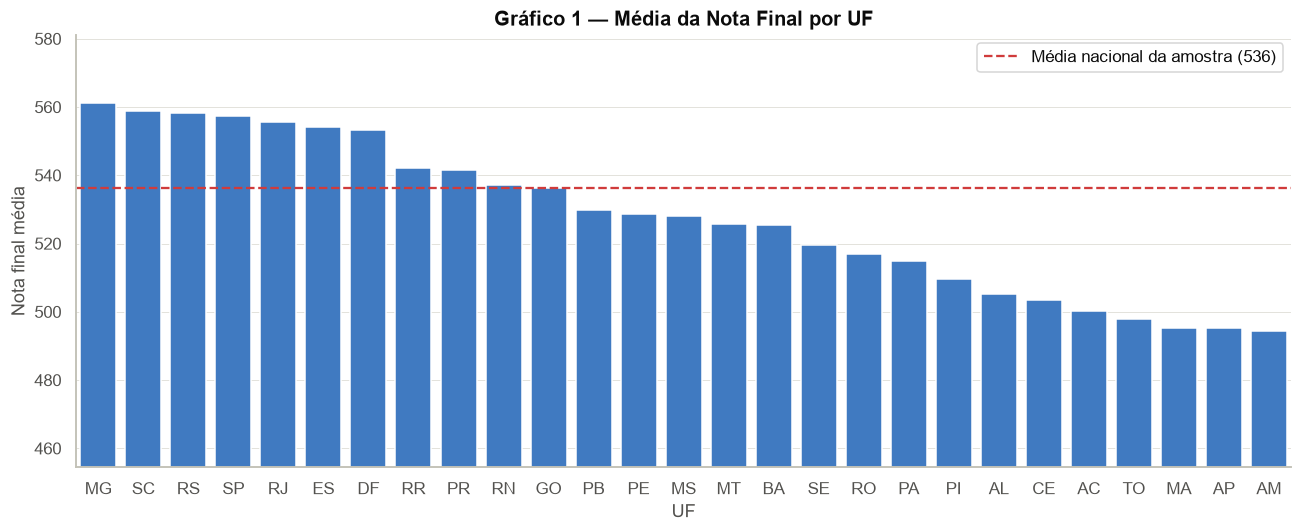

In [6]:
# ---------- Gráfico 1: Média da Nota Final por UF ----------
ordem_uf = media_uf.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=ordem_uf.index, y=ordem_uf.values, color=AZUL, ax=ax)
ax.axhline(df_pres["NOTA_FINAL"].mean(), color=DESTAQUE, ls="--", lw=1.5,
           label=f"Média nacional da amostra ({df_pres['NOTA_FINAL'].mean():.0f})")
ax.set(title="Gráfico 1 — Média da Nota Final por UF", xlabel="UF", ylabel="Nota final média",
       ylim=(max(0, ordem_uf.min() - 40), ordem_uf.max() + 20))
ax.legend()
plt.tight_layout(); plt.show()

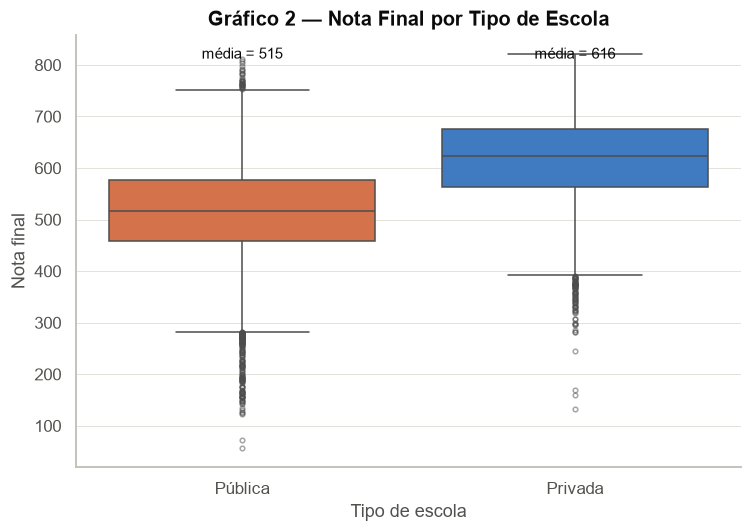

In [7]:
# ---------- Gráfico 2: Notas por tipo de escola (Boxplot) ----------
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_pres, x="TP_ESCOLA", y="NOTA_FINAL", hue="TP_ESCOLA", order=["Pública", "Privada"],
            hue_order=["Pública", "Privada"], palette=[CORES_ESCOLA["Pública"], CORES_ESCOLA["Privada"]], legend=False,
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}, ax=ax)
for i, tp in enumerate(["Pública", "Privada"]):
    ax.text(i, df_pres["NOTA_FINAL"].max() * 0.99, f"média = {med_escola[tp]:.0f}", ha="center", fontsize=10)
ax.set(title="Gráfico 2 — Nota Final por Tipo de Escola", xlabel="Tipo de escola", ylabel="Nota final")
plt.tight_layout(); plt.show()

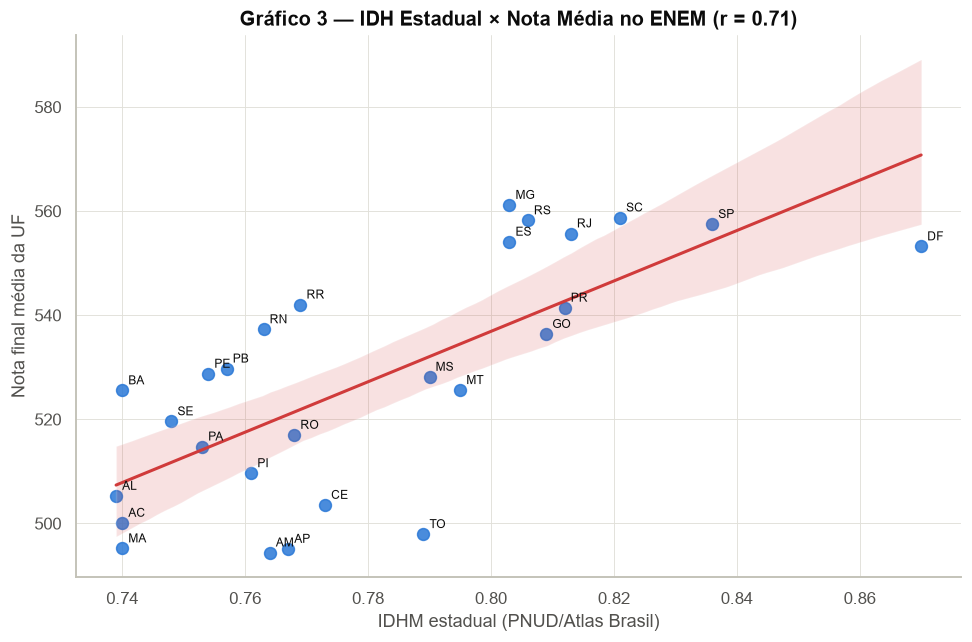

In [8]:
# ---------- Gráfico 3: IDH × Nota média (scatter + tendência) ----------
dados3 = tab_uf.dropna(subset=["NOTA_MEDIA"]).reset_index()
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=dados3, x="IDH_ESTADUAL", y="NOTA_MEDIA", ci=95,
            scatter_kws={"s": 60, "color": AZUL, "alpha": 0.85},
            line_kws={"color": DESTAQUE, "lw": 2}, ax=ax)
for _, r in dados3.iterrows():
    ax.annotate(r["UF"], (r["IDH_ESTADUAL"], r["NOTA_MEDIA"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set(title=f"Gráfico 3 — IDH Estadual × Nota Média no ENEM (r = {corr_idh:.2f})",
       xlabel="IDHM estadual (PNUD/Atlas Brasil)", ylabel="Nota final média da UF")
plt.tight_layout(); plt.show()

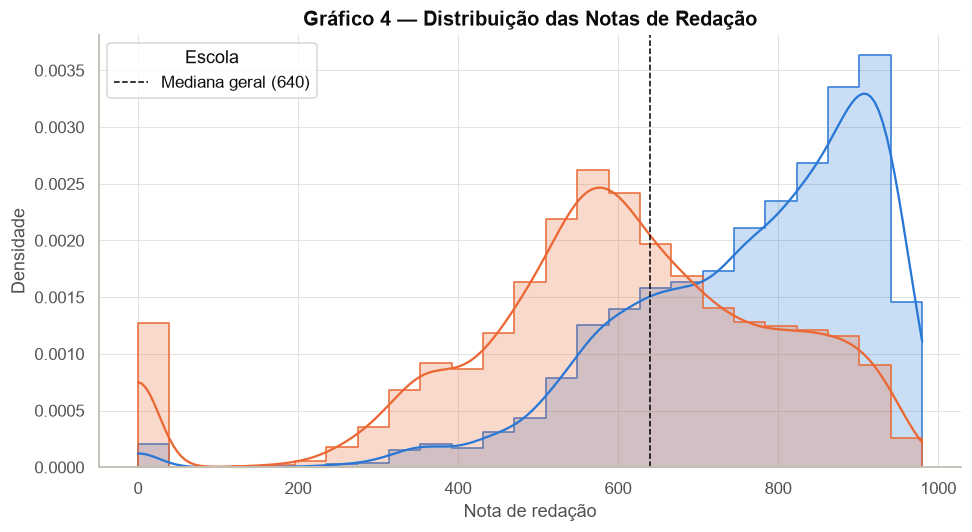

In [9]:
# ---------- Gráfico 4: Distribuição das notas de Redação ----------
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df_pres, x="NU_NOTA_REDACAO", hue="TP_ESCOLA", bins=25, kde=True, stat="density",
             common_norm=False, element="step", palette=CORES_ESCOLA, ax=ax)
ax.axvline(df_pres["NU_NOTA_REDACAO"].median(), color="black", ls="--", lw=1,
           label=f"Mediana geral ({df_pres['NU_NOTA_REDACAO'].median():.0f})")
ax.set(title="Gráfico 4 — Distribuição das Notas de Redação", xlabel="Nota de redação", ylabel="Densidade")
ax.legend(title="Escola", loc="upper left")
plt.tight_layout(); plt.show()

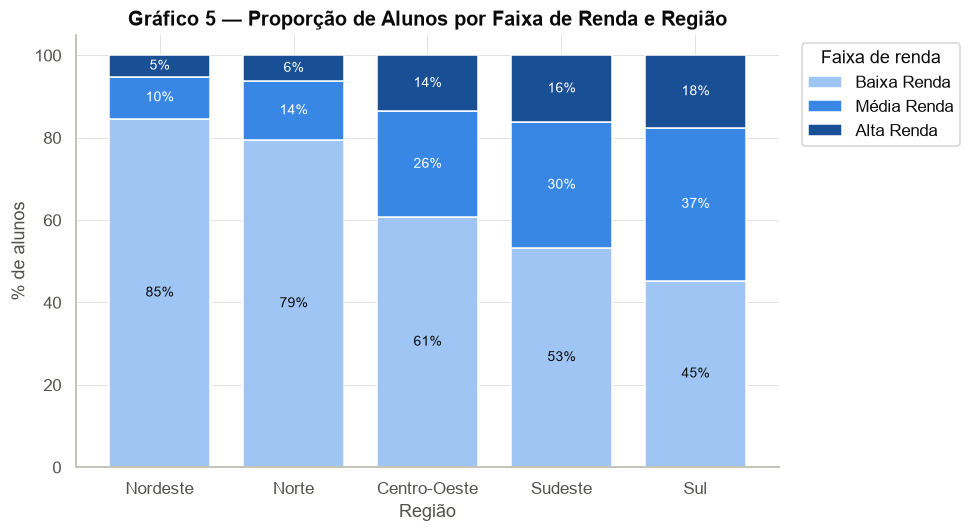

In [10]:
# ---------- Gráfico 5: Faixa de renda por Região (barras empilhadas, 100%) ----------
prop = (pd.crosstab(df["REGIAO"], df["FAIXA_RENDA"], normalize="index") * 100)[["Baixa Renda", "Média Renda", "Alta Renda"]]
prop = prop.sort_values("Baixa Renda", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
prop.plot(kind="bar", stacked=True, color=[CORES_RENDA[c] for c in prop.columns], width=0.75, ax=ax)
# Rótulo escuro no tom mais claro e branco nos escuros, para manter o contraste
for cont, cor_texto in zip(ax.containers, ["#0b0b0b", "white", "white"]):
    ax.bar_label(cont, fmt="%.0f%%", label_type="center", color=cor_texto, fontsize=9)
ax.set(title="Gráfico 5 — Proporção de Alunos por Faixa de Renda e Região", xlabel="Região", ylabel="% de alunos")
ax.legend(title="Faixa de renda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 7. Síntese para o storytelling
Use os KPIs e gráficos acima para estruturar o relatório (os números são reprodutíveis: amostra e simulação usam `SEED = 42`):
- **Desigualdade escolar:** razão Privada/Pública (KPI B3) e Gráfico 2.
- **Território:** correlação IDH × nota (KPI C1), gap entre UFs (C2), índice de desigualdade regional (C5) e Gráficos 1 e 3.
- **Acesso:** abstenção por renda (C4) e Gráfico 5 mostram quem sequer chega à prova.
- **Mobilidade:** % de baixa renda com nota > 600 (D3) como indicador de "exceções" à regra.

**Limitações a declarar no relatório:** correlação ecológica (nível UF) não implica causalidade individual; a amostra não é probabilística em relação à população jovem do país, porque cobre apenas quem se inscreveu no ENEM 2023 e é concluinte; a UF considerada é a da prova, não a de residência; IDHM e renda per capita são médias estaduais, iguais para todos os alunos da mesma UF.